In [ ]:
!apt update
!apt install openjdk-17-jdk -y

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
51 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree

In [ ]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
pip install capymoa

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

files.upload()      # selecione kaggle.json

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"luanmoon","key":"1eefa35a0c2c6451f15ab3d5a7af5217"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download \
-d ymirsky/network-attack-dataset-kitsune

Dataset URL: https://www.kaggle.com/datasets/ymirsky/network-attack-dataset-kitsune
License(s): GNU Affero General Public License 3.0
network-attack-dataset-kitsune.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q network-attack-dataset-kitsune.zip -d kitsune

replace kitsune/ARP MitM/ARP_MitM_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

for raiz, _, arquivos in os.walk("kitsune"):
    for arquivo in arquivos:
        print(os.path.join(raiz, arquivo))

kitsune/ARP MitM/ARP_MitM_dataset.csv


## Experimento 2

Dataset kitsune com aprendizado não supervisionado tradicional em cenário online(Simulado)

In [ ]:
dataset = pd.read_csv("kitsune/ARP MitM/ARP_MitM_dataset.csv")


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from capymoa.stream import CSVStream

# ==========================
# Carregar dataset original
# ==========================

dataset = pd.read_csv("kitsune/ARP MitM/ARP_MitM_dataset.csv")

print("Dataset original:", dataset.shape)

# ==========================
# Amostragem
# ==========================

sample_size = 10000

dataset, _ = train_test_split(
    dataset,
    train_size=sample_size,
    random_state=42,
    shuffle=True
)

dataset = dataset.reset_index(drop=True)

print("Dataset amostrado:", dataset.shape)

# ==========================
# Criar coluna dummy_label
# (necessária apenas para o CSVStream)
# ==========================

dataset["dummy_label"] = "0"

print(dataset.head())

# ==========================
# Salvar novo dataset
# ==========================

csv_path = "kitsune_sample_10000.csv"

dataset.to_csv(
    csv_path,
    index=False
)

print("Arquivo salvo:", csv_path)

# ==========================
# Criar Stream
# ==========================

stream = CSVStream(
    file=csv_path,
    target="dummy_label",
    categories={"dummy_label": ["0"]},
    name="Kitsune Stream",
    length=len(dataset)
)

print(stream.schema)

Dataset original: (63413, 115)
Dataset amostrado: (10000, 115)
   1.000000000000000000e+00  1.294000000000000000e+03  \
0                470.550769               1341.843723   
1                371.408392               1329.466116   
2                383.781507               1339.601091   
3                 31.752078                 61.971880   
4                353.131589               1331.103831   

   0.000000000000000000e+00  1.000000000000000000e+00.1  \
0             174021.366855                  748.596026   
1             192696.593858                  637.480038   
2             180313.877289                  651.182882   
3                345.134444                   43.445880   
4             182773.714499                  611.211484   

   1.294000000000000000e+03.1  0.000000000000000000e+00.1  \
0                 1342.027709               175639.168972   
1                 1336.991666               185951.507046   
2                 1342.670644               177438.54124

In [ ]:
rows = []

while stream.has_more_instances():

    instance = stream.next_instance()

    rows.append(instance.x)

In [ ]:
X = pd.DataFrame(rows)

print(X.shape)

(10000, 115)


In [ ]:
# Pré-processamento
dataset = dataset.fillna(0)

dataset = dataset.replace(
    [np.inf, -np.inf],
    0
)

X = dataset.copy()

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(X)

print("Dimensão original :", X.shape[1])

print("Após PCA :", X_pca.shape[1])

Dimensão original : 116
Após PCA : 15


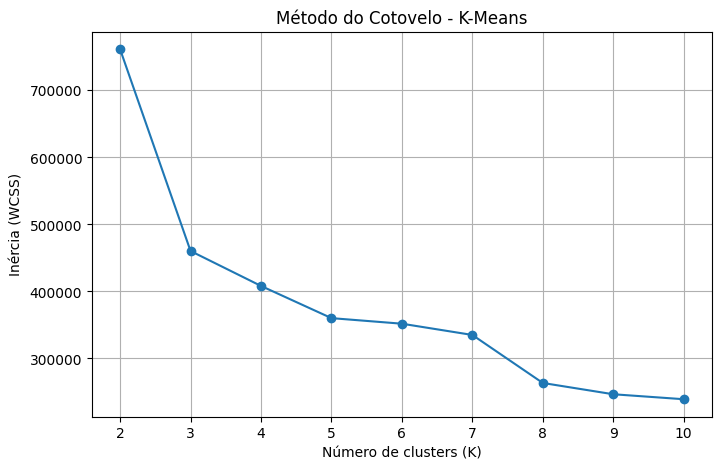

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Valores de K a serem testados
ks = range(2, 11)

inertias = []

for k in ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X_pca)

    inertias.append(model.inertia_)

# Plot do método do cotovelo
plt.figure(figsize=(8,5))

plt.plot(
    ks,
    inertias,
    marker='o'
)

plt.title("Método do Cotovelo - K-Means")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.xticks(ks)
plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

labels_kmeans = kmeans.fit_predict(X_pca)

sil_kmeans = silhouette_score(
    X_pca,
    labels_kmeans
)

In [ ]:
hier = AgglomerativeClustering(
    n_clusters=3
)

labels_hier = hier.fit_predict(X_pca)

sil_hier = silhouette_score(
    X_pca,
    labels_hier
)

In [ ]:
db = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels_db = db.fit_predict(X_pca)

In [ ]:
n_clusters_db = len(
    set(labels_db)
    -
    {-1}
)

In [ ]:
noise_ratio = np.mean(
    labels_db==-1
)

print("Ruído:",noise_ratio)

Ruído: 0.3527


In [ ]:
if n_clusters_db > 1:

    sil_db = silhouette_score(
        X_pca[labels_db!=-1],
        labels_db[labels_db!=-1]
    )

else:

    sil_db = np.nan

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

Y = tsne.fit_transform(X_pca)

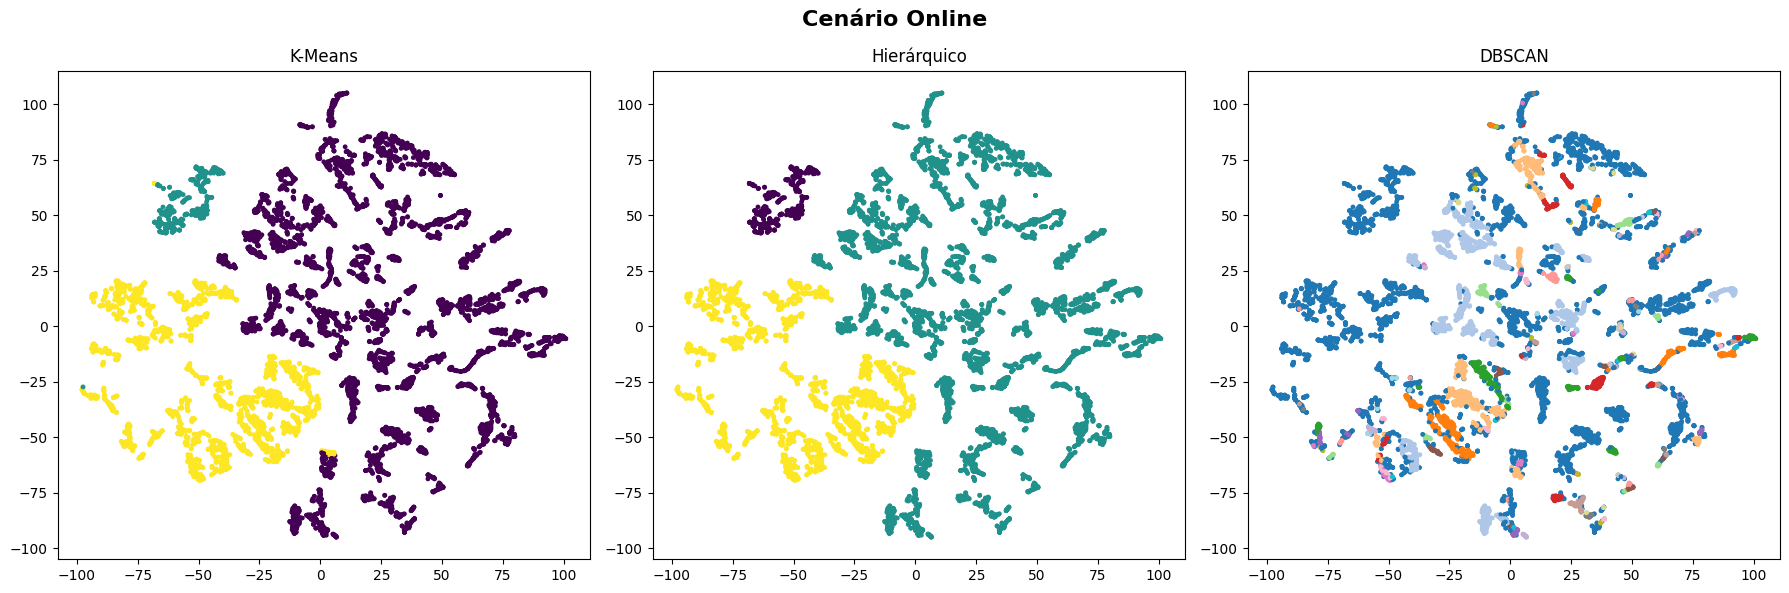

In [ ]:
fig,axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

fig.suptitle(
    "Cenário Online",
    fontsize=16,
    fontweight="bold"
)

axes[0].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_kmeans,
    s=6
)

axes[0].set_title("K-Means")

axes[1].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_hier,
    s=6
)

axes[1].set_title("Hierárquico")

axes[2].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_db,
    s=6,
    cmap="tab20"
)

axes[2].set_title("DBSCAN")

plt.tight_layout()

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Algoritmo":[
        "K-Means",
        "Hierárquico",
        "DBSCAN"
    ],

    "Clusters":[
        len(np.unique(labels_kmeans)),
        len(np.unique(labels_hier)),
        n_clusters_db
    ],

    "Silhouette":[
        sil_kmeans,
        sil_hier,
        sil_db
    ],

    "Ruído (%)":[
        0,
        0,
        noise_ratio*100
    ]

})

comparison

,Algoritmo,Clusters,Silhouette,Ruído (%)
0,K-Means,3,0.488719,0.00
1,Hierárquico,3,0.488958,0.00
2,DBSCAN,173,0.110682,35.27


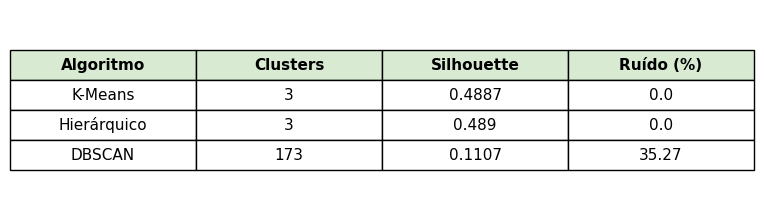

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Tabela dos resultados
# ==========================

fig, ax = plt.subplots(figsize=(8, 2.6))

ax.axis("off")

# Arredondamento dos valores
comparison_plot = comparison.copy()

comparison_plot["Silhouette"] = comparison_plot["Silhouette"].round(4)
comparison_plot["Ruído (%)"] = comparison_plot["Ruído (%)"].round(2)

table = ax.table(
    cellText=comparison_plot.values,
    colLabels=comparison_plot.columns,
    cellLoc='center',
    loc='center'
)

# Estilo
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Cabeçalho
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#D9EAD3')   # verde claro
    else:
        cell.set_facecolor('white')

plt.title(
    "",
    fontsize=12,
    weight='bold',
    pad=15
)

plt.savefig(
    "tabela_offline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()